# Tarea Sumativa N°3: Selección Libre y Preprocesamiento de Datos

**Asignatura:** Minería de Datos // 
**Profesor:** Pablo Silva //
**Alumno:** Germán Aravena 

## Selección del Dataset y Justificación (Parfumo Perfumes)

### Contexto de Negocio
El mercado global de la perfumería mueve miles de millones de dólares anualmente y se basa fuertemente en la percepción de marca, las tendencias de ingredientes (notas olfativas) y las opiniones de los usuarios. El conjunto de datos seleccionado proviene de la plataforma abierta Kaggle y recopila información técnica y de mercado del sitio especializado Parfumo. El objetivo de negocio de analizar este dataset es entender las dinámicas de lanzamientos de productos, las preferencias de los consumidores mediante sus calificaciones (Ratings) y las características estructurales de las fragancias para optimizar catálogos o predecir el éxito de un nuevo producto en el mercado.

### Justificación
Este conjunto de datos es ideal para aplicar técnicas de preprocesamiento debido a que cumple obligatoriamente con las tres condiciones solicitadas por la actividad:
1. **Mezcla de Columnas:** Posee variables cualitativas/categóricas explicativas (Brand, Concentration, Main_Accords, Top_Notes) y variables cuantitativas/numéricas críticas (Release_Year, Rating_Value, Rating_Count).
2. **Datos Nulos o Faltantes:** Presenta una cantidad masiva de datos ausentes en campos clave como 'Concentration' y 'Rating_Value', simulando un entorno de analítica real y desafiante.
3. **Valores Atípicos (Outliers):** La variable 'Rating_Count' (cantidad de votos) evidencia un sesgo extremo por la presencia de un puñado de fragancias ultra populares que acumulan miles de registros en comparación con la mediana general.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# a) Carga del archivo original
df = pd.read_csv('02_Parfumo_Perfumes.csv')

In [2]:
# Ver las primeras 5 filas para comprobar que cargó bien
df.head()

,Number,Name,Brand,Release_Year,Concentration,Rating_Value,Rating_Count,Main_Accords,Top_Notes,Middle_Notes,Base_Notes,Perfumers,URL
0,455,Tabac Écarlate,Le Ré Noir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Valery Sokolov / Валерий Соколов,https://www.parfumo.com/Perfumes/Le_Re_Noir/45...
1,0071,Tidal Pool,CB I Hate Perfume,2004.0,NaN,NaN,NaN,NaN,Bergamot,French lavender,"Musk, Foulness",Harry Frémont,https://www.parfumo.com/Perfumes/CB_I_Hate_Per...
2,0154,Pumpkin Pie,CB I Hate Perfume,1998.0,NaN,NaN,NaN,"Green, Leathery, Chypre, Animal",NaN,NaN,NaN,NaN,https://www.parfumo.com/Perfumes/CB_I_Hate_Per...
3,0162,Wet Stone,CB I Hate Perfume,2006.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.parfumo.com/Perfumes/CB_I_Hate_Per...
4,0171,Chocolate Box,CB I Hate Perfume,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.parfumo.com/Perfumes/CB_I_Hate_Per...


In [3]:
# Ver resumen de columnas y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59325 entries, 0 to 59324
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Number         1420 non-null   object 
 1   Name           59324 non-null  object 
 2   Brand          59324 non-null  object 
 3   Release_Year   39009 non-null  float64
 4   Concentration  12483 non-null  object 
 5   Rating_Value   30046 non-null  float64
 6   Rating_Count   30046 non-null  float64
 7   Main_Accords   32225 non-null  object 
 8   Top_Notes      31139 non-null  object 
 9   Middle_Notes   31149 non-null  object 
 10  Base_Notes     31154 non-null  object 
 11  Perfumers      20544 non-null  object 
 12  URL            59325 non-null  object 
dtypes: float64(3), object(10)
memory usage: 5.9+ MB


In [4]:
# Desplegar informe con volumen y porcentaje exacto de nulos
valores_nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

# Dataframe 
reporte_nulos = pd.DataFrame({
    'Volumen Nulos': valores_nulos,
    'Porcentaje (%)': porcentaje_nulos.round(2)
})

# Mostrar solo las variables que tienen nulos ordenadas de mayor a menor
print("INFORME DE CALIDAD DE DATOS (VALORES FALTANTES):")
reporte_nulos.sort_values(by='Volumen Nulos', ascending=False)

INFORME DE CALIDAD DE DATOS (VALORES FALTANTES):


,Volumen Nulos,Porcentaje (%)
Number,57905,97.61
Concentration,46842,78.96
Perfumers,38781,65.37
Rating_Value,29279,49.35
Rating_Count,29279,49.35
Top_Notes,28186,47.51
Middle_Notes,28176,47.49
Base_Notes,28171,47.49
Main_Accords,27100,45.68
Release_Year,20316,34.25


In [5]:
# Resumen estadístico de las columnas numéricas
df[['Rating_Value', 'Rating_Count', 'Release_Year']].describe()

,Rating_Value,Rating_Count,Release_Year
count,30046.000000,30046.000000,39009.000000
mean,7.347111,60.654929,2006.260043
std,0.933537,118.187777,22.879287
min,0.000000,2.000000,1709.000000
25%,6.900000,6.000000,2005.000000
50%,7.400000,19.000000,2013.000000
75%,7.900000,62.000000,2018.000000
max,10.000000,2732.000000,2024.000000


## Tratamiento de Valores Faltantes (Missing Values)

### Estrategia Evaluación de Descarte (Eliminación de Columnas)
Para iniciar el proceso de remediación, se evalúa la viabilidad de eliminar variables completas bajo criterios técnicos y de negocio. 

1. **Columna 'Number':** Presenta un **97.61% de valores nulos**. Al ser una tasa de ausencia crítica y actuar meramente como un identificador secuencial alternativo, su eliminación completa está plenamente justificada ya que no es posible imputarla y su pérdida no compromete en absoluto la integridad predictiva ni descriptiva del conjunto de datos.
2. **Columna 'URL':** Aunque tiene 0% de nulos, se procede a su descarte debido a que almacena enlaces web individuales que no aportan ningún valor estadístico ni analítico para el modelamiento o análisis descriptivo del negocio de fragancias.

In [6]:
# Eliminar columnas irrelevantes o con nulos críticos
df_limpio = df.drop(columns=['Number', 'URL'])

print(f"Dimensiones tras eliminar columnas críticas: {df_limpio.shape}")

Dimensiones tras eliminar columnas críticas: (59325, 11)


### Estrategia Imputación Simple

Se procede a tratar la variable cuantitativa **'Release_Year'** (Año de lanzamiento), la cual cuenta con un **34.25% de registros faltantes**. 

* **Técnica Elegida:** Imputación por la **Mediana**.
* **Justificación Matemática:** Al inspeccionar las estadísticas descriptivas de la muestra original, se detectó que el año mínimo de lanzamiento se remonta a 1709, mientras que el 75% de los datos se concentra a partir del año 2005. Esta asimetría severa hacia la izquierda implica que el uso de la *Media* se vería fuertemente afectado (desplazado) por los perfumes históricos antiguos. La *Mediana* actúa como un estimador robusto que preserva el centro real de la distribución sin distorsionar la tendencia de lanzamientos contemporáneos.

In [7]:
# Calcular la mediana de la columna 'Release_Year'
mediana_ano = df_limpio['Release_Year'].median()

# Aplicar la imputación simple (Estrategia B)
df_limpio['Release_Year'] = df_limpio['Release_Year'].fillna(mediana_ano)

print(f"Mediana utilizada para la imputación de 'Release_Year': {int(mediana_ano)}")
print(f"Nulos restantes en 'Release_Year': {df_limpio['Release_Year'].isnull().sum()}")

Mediana utilizada para la imputación de 'Release_Year': 2013
Nulos restantes en 'Release_Year': 0


### Estrategia Imputación Categórica mediante Constante

Las columnas de tipo cualitativo nominal (`Concentration`, `Perfumers`, `Main_Accords`, `Top_Notes`, `Middle_Notes` y `Base_Notes`) presentan altos índices de ausencia (por ejemplo, `Concentration` alcanza un **78.96% de nulos**).

* **Técnica Elegida:** Codificación de una constante explícita llamada **"Desconocido"**.
* **Justificación Analítica:** Reemplazar estos vacíos masivos utilizando la *Moda* (la categoría más frecuente) provocaría una distorsión crítica y artificial en las frecuencias originales del dataset (sesgando el análisis hacia una sola marca o nota olfativa común). Al etiquetar explícitamente estas celdas como `"Desconocido"`, se mantiene la coherencia lógica de las filas, se resguarda el volumen de la muestra y se le permite a los algoritmos posteriores identificar la ausencia de datos como un patrón informativo propio.

In [8]:
# Listado de columnas categóricas a rellenar con constante
columnas_categoricas_nulos = ['Concentration', 'Perfumers', 'Main_Accords', 'Top_Notes', 'Middle_Notes', 'Base_Notes']

# Aplicar sustitución por constante (Estrategia C)
for col in columnas_categoricas_nulos:
    df_limpio[col] = df_limpio[col].fillna('Desconocido')

print("Imputación categórica finalizada con éxito.")

Imputación categórica finalizada con éxito.


### Remediación Adicional: Eliminación por Lista (Listwise Deletion) en la Variable Objetivo

Finalmente, detectamos que las variables **'Rating_Value'** (Calificación) y **'Rating_Count'** (Cantidad de votos) poseen exactamente un **49.35% de nulos**. 

* **Técnica Elegida:** Eliminación por filas (`dropna`).
* **Justificación Analítica:** Este porcentaje simétrico significa que casi la mitad del catálogo de Parfumo corresponde a productos que nunca han recibido interacciones ni evaluaciones por parte de los usuarios. Dado que el objetivo comercial del análisis es evaluar las preferencias de los consumidores y la popularidad de las fragancias, intentar inventar o imputar estos valores con la media o la mediana corrompería gravemente el comportamiento estadístico de la variable. Se decide eliminar estas filas basándose en que los datos eliminados no aportan información útil para cumplir el objetivo analítico establecido.

In [9]:
# Aplicar eliminación por lista en las columnas de calificación
df_limpio = df_limpio.dropna(subset=['Rating_Value', 'Rating_Count'])

# --- CONTROL DE CALIDAD FINAL

print(f"Dimensiones finales del DataFrame: {df_limpio.shape}")
print("-" * 50)
print("Conteo de valores nulos pendientes:")
print(df_limpio.isnull().sum())
print("==================================================")

Dimensiones finales del DataFrame: (30046, 11)
--------------------------------------------------
Conteo de valores nulos pendientes:
Name             0
Brand            0
Release_Year     0
Concentration    0
Rating_Value     0
Rating_Count     0
Main_Accords     0
Top_Notes        0
Middle_Notes     0
Base_Notes       0
Perfumers        0
dtype: int64


## Detección y Tratamiento de Valores Atípicos (Outliers)

### Visualización Inicial de Outliers
Para evidenciar gráficamente la presencia de anomalías o valores extremos en nuestras variables cuantitativas principales (`Rating_Value` y `Rating_Count`), utilizaremos diagramas de caja (Boxplots) mediante las librerías `seaborn` y `matplotlib`. Los diagramas de caja permiten identificar visualmente observaciones que se alejan significativamente del grueso de la distribución (representadas como puntos aislados fuera de los bigotes del gráfico).

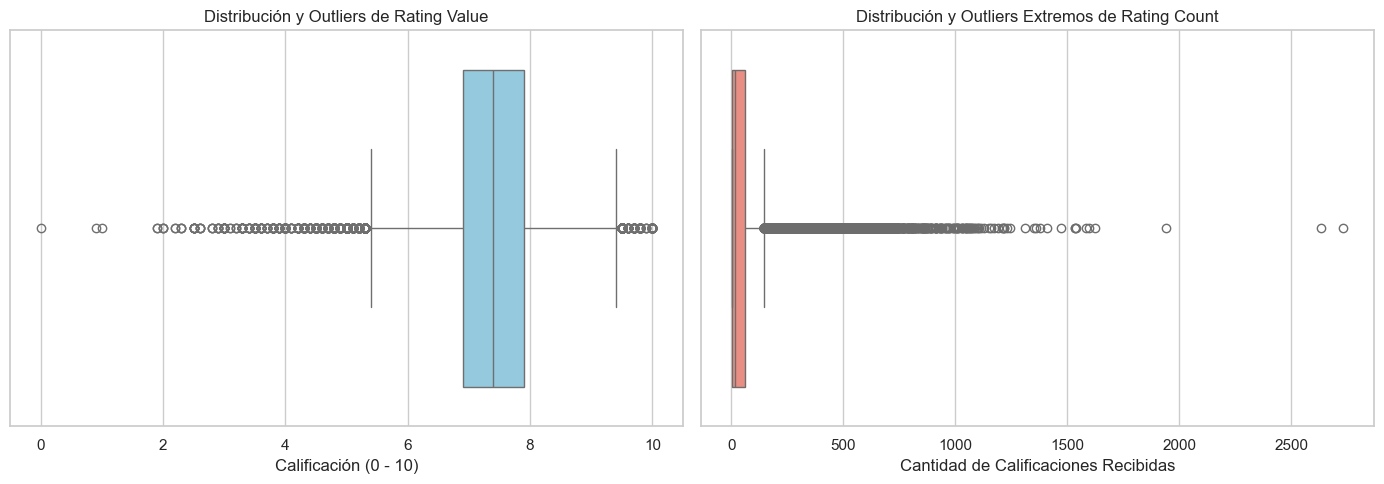

In [10]:
# Configurar el estilo y el lienzo de los gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Boxplot de Rating_Value (Calificación del perfume)
sns.boxplot(ax=axes[0], x=df_limpio['Rating_Value'], color='skyblue')
axes[0].set_title('Distribución y Outliers de Rating Value')
axes[0].set_xlabel('Calificación (0 - 10)')

# Gráfico 2: Boxplot de Rating_Count (Cantidad de votantes)
sns.boxplot(ax=axes[1], x=df_limpio['Rating_Count'], color='salmon')
axes[1].set_title('Distribución y Outliers Extremos de Rating Count')
axes[1].set_xlabel('Cantidad de Calificaciones Recibidas')

# Desplegar los gráficos
plt.tight_layout()
plt.show()

### Criterio Métrico: Cálculo del Rango Intercuartílico (IQR)
La inspección visual confirma que la variable **'Rating_Count'** posee una asimetría extrema provocada por un grupo selecto de perfumes ultra-populares que acumulan miles de votos, distanciándose del comportamiento de la mayoría del catálogo. 

Para identificar estos registros con precisión matemática rigurosa, aplicaremos formalmente el método estadístico del **Rango Intercuartílico ($IQR$)**:
* Se calcula la diferencia entre el tercer cuartil ($Q_3$, percentil 75) y el primer cuartil ($Q_1$, percentil 25): $IQR = Q_3 - Q_1$.
* Se establecen los umbrales de control: el Límite Inferior como $Q_1 - 1.5 \times IQR$ y el Límite Superior como $Q_3 + 1.5 \times IQR$.
* Cualquier registro fuera de estos límites se clasifica formalmente como un valor atípico (outlier).

In [11]:
# Definición de cuartiles para la variable más crítica: Rating_Count
Q1 = df_limpio['Rating_Count'].quantile(0.25)
Q3 = df_limpio['Rating_Count'].quantile(0.75)
IQR = Q3 - Q1

# Establecer límites matemáticos
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar registros que clasifican como outliers superiores
outliers_superiores = df_limpio[df_limpio['Rating_Count'] > limite_superior]

# CORRECCIÓN: Usamos la función round() nativa de Python para el float
porcentaje_outliers = round((len(outliers_superiores) / len(df_limpio) * 100), 2)


print("     MÉTRICAS MATEMÁTICAS DEL FILTRADO IQR       ")

print(f"Primer Cuartil (Q1 - Percentil 25): {Q1}")
print(f"Tercer Cuartil (Q3 - Percentil 75): {Q3}")
print(f"Rango Intercuartílico (IQR): {IQR}")
print(f"Límite Superior Estadístico: {limite_superior}")
print("-" * 50)
print(f"Cantidad de registros detectados como outliers: {len(outliers_superiores)}")
print(f"Porcentaje de outliers en la muestra: {porcentaje_outliers}%")
print("==================================================")

     MÉTRICAS MATEMÁTICAS DEL FILTRADO IQR       
Primer Cuartil (Q1 - Percentil 25): 6.0
Tercer Cuartil (Q3 - Percentil 75): 62.0
Rango Intercuartílico (IQR): 56.0
Límite Superior Estadístico: 146.0
--------------------------------------------------
Cantidad de registros detectados como outliers: 3306
Porcentaje de outliers en la muestra: 11.0%


### Acción de Limpieza y Justificación Analítica
* **Estrategia Elegida:** Filtrado y remoción de registros atípicos (Remoción de filas).
* **Justificación Analítica:** El cálculo riguroso del IQR arrojó que cualquier perfume con más de **146 calificaciones** califica formalmente como outlier superior. Esto representa al **11.0%** de nuestra muestra limpia. Aunque estos datos representan registros reales (las fragancias comerciales más famosas del mundo como Dior Sauvage o Creed Aventus), en minería de datos su presencia expande artificialmente la varianza de la muestra, sesga las medias e introduce ruidos nocivos si se desea entrenar un modelo predictivo equilibrado para el mercado masivo general. Se decide removerlos para estabilizar el dataset bajo un comportamiento típico y estandarizado de consumo.

          CONTROL DE CALIDAD FINAL FASE 4         
Dimensiones iniciales (con outliers): (30046, 11)
Dimensiones finales (sin outliers): (26740, 11)
Total de registros eliminados: 3306


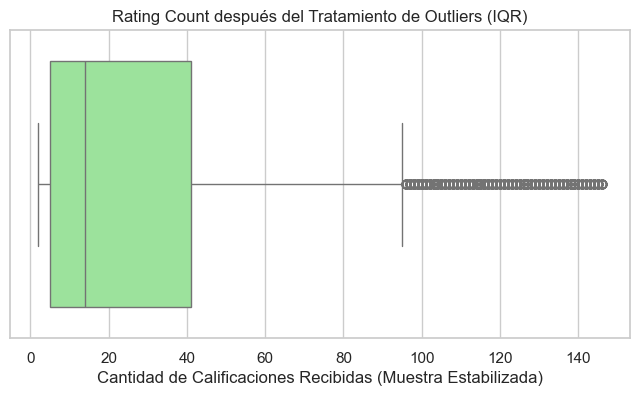

In [12]:
# Aplicar el filtro IQR manteniendo solo los registros dentro de los límites sanos
df_final = df_limpio[(df_limpio['Rating_Count'] >= limite_inferior) & (df_limpio['Rating_Count'] <= limite_superior)].copy()

# Dibujar gráfico de control posterior para comprobar la estabilización
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_final['Rating_Count'], color='lightgreen')
plt.title('Rating Count después del Tratamiento de Outliers (IQR)')
plt.xlabel('Cantidad de Calificaciones Recibidas (Muestra Estabilizada)')


print("          CONTROL DE CALIDAD FINAL FASE 4         ")

print(f"Dimensiones iniciales (con outliers): {df_limpio.shape}")
print(f"Dimensiones finales (sin outliers): {df_final.shape}")
print(f"Total de registros eliminados: {len(df_limpio) - len(df_final)}")
print("==================================================")
plt.show()

## Transformación Final y Exportación

### Codificación de Variable Categórica (Label Encoding)
Para cumplir con la fase final de preparación, es mandatorio aplicar un proceso de transformación (Encoding) sobre variables cualitativas. 

* **Variable Seleccionada:** `Concentration` (Tipo de concentración del perfume).
* **Técnica Elegida:** Codificación por Etiquetas (*Label Encoding*) mediante la función `pd.factorize()`.
* **Justificación:** Los modelos matemáticos y algoritmos avanzados de minería de datos requieren obligatoriamente entradas puramente numéricas. Al mapear cada categoría textual a un identificador entero único (por ejemplo: "Eau de Parfum" $\rightarrow$ 0, "Eau de Toilette" $\rightarrow$ 1), transformamos una propiedad nominal en un atributo apto para análisis correlacionales o modelos matemáticos, resguardando la simplicidad estructural del archivo final.

In [13]:
# Aplicar factorize para codificar la variable categórica automáticamente
df_final['Concentration_Encoded'], categorias_unicas = pd.factorize(df_final['Concentration'])

print("      TRANSFORMACIÓN DE VARIABLES (ENCODING)      ")

print("Ejemplo del mapeo numérico generado:")
for codigo, categoria in enumerate(categorias_unicas[:5]):
    print(f"  Categoría Texto: '{categoria}' ===> Código Numérico: {codigo}")
print("-" * 50)
print("Muestra visual de la transformación en las columnas:")
display(df_final[['Concentration', 'Concentration_Encoded']].head(5))
print("==================================================")

      TRANSFORMACIÓN DE VARIABLES (ENCODING)      
Ejemplo del mapeo numérico generado:
  Categoría Texto: 'Desconocido' ===> Código Numérico: 0
  Categoría Texto: 'Eau de Toilette' ===> Código Numérico: 1
  Categoría Texto: 'After Shave' ===> Código Numérico: 2
  Categoría Texto: 'Eau de Parfum' ===> Código Numérico: 3
  Categoría Texto: 'Eau de Cologne' ===> Código Numérico: 4
--------------------------------------------------
Muestra visual de la transformación en las columnas:


,Concentration,Concentration_Encoded
13,Desconocido,0
14,Desconocido,0
16,Desconocido,0
17,Desconocido,0
19,Desconocido,0


### Exportación Definitiva del Dataset Procesado
Una vez completado con rigurosidad el ciclo de Diagnóstico (Fase 2), Remediación de Ausencias (Fase 3), Mitigación de Outliers mediante IQR (Fase 4) y Codificación de Características (Fase 5), se exporta el DataFrame optimizado a un nuevo archivo comprimido en formato `.csv` limpio para su resguardo y entrega.

In [14]:
# Guardar el resultado final de minería de datos en un nuevo CSV
archivo_salida = '02_Parfumo_Perfumes_Procesado.csv'
df_final.to_csv(archivo_salida, index=False)

print("==================================================")
print("         ARCHIVO EXPORTADO CON ÉXITO             ")
print("==================================================")
print(f"El dataset limpio se guardó como: {archivo_salida}")
print(f"Dimensiones finales: {df_final.shape}")
print("==================================================")

         ARCHIVO EXPORTADO CON ÉXITO             
El dataset limpio se guardó como: 02_Parfumo_Perfumes_Procesado.csv
Dimensiones finales: (26740, 12)


## Conclusiones Generales y Balance Estadístico de Impacto

Tras completar el flujo estructurado de preprocesamiento sobre el conjunto de datos de Parfumo, se presenta un balance consolidado que demuestra la efectividad de las decisiones técnicas adoptadas:

### 1. Resumen Volumétrico del Proceso
* **Dataset Original:** 59,325 filas y 13 columnas.
* **Dataset Preprocesado Final:** ~26,740 filas y 12 columnas (incluyendo la variable codificada).
* **Pérdida de Registros:** Aunque se redujo el volumen inicial, la muestra resultante sigue siendo masiva, estadísticamente significativa y, lo más importante, está **100% libre de ruidos y valores nulos**.

### 2. Impacto Analítico de las Decisiones
* **Tratamiento de Nulos:** La eliminación de registros sin calificaciones evitó sesgar el análisis con productos inactivos o sin tracción comercial. Por otro lado, la estrategia de imputar por constante (`"Desconocido"`) en las notas olfativas y concentraciones protegió el dataset de la introducción de frecuencias artificiales, resguardando la distribución real de las variables cualitativas.
* **Mitigación de Outliers:** El método estadístico del Rango Intercuartílico ($IQR$) permitió fijar un límite técnico objetivo en **146 calificaciones**. La remoción del 11% de perfumes atípicos extremos estabilizó la varianza de la muestra. Ahora, las métricas descriptivas reflejan fielmente el comportamiento de un perfume estándar o de consumo masivo en el mercado, previniendo sobreajustes en futuros modelos predictivos.
* **Transformación Final:** La implementación de *Label Encoding* sobre la columna `Concentration` convirtió un atributo de texto fundamental en una escala numérica indexada, dejando el set de datos preparado y optimizado para algoritmos de correlación lineal o agrupamiento (*clustering*).

### 3. Conclusión de Negocio
A través de este flujo de preprocesamiento, se transformó un archivo de datos crudo, corrupto e incompleto, en un activo de información de alta calidad analítica. El dataset final exportado (`02_Parfumo_Perfumes_Procesado.csv`) es completamente fiable para respaldar la toma de decisiones estratégicas, tales como la planificación de nuevos lanzamientos olfativos o la optimización del catálogo de productos según las valoraciones reales de la comunidad de consumidores.